# Détection et classification des tomates malades avec YOLOv8

Ce notebook contient tout le pipeline demandé :

1. Import du dataset YOLOv8 annoté avec `train`, `valid`, `test` et `data.yaml`
2. Vérification / preprocessing du dataset
3. Visualisation des images et des bounding boxes
4. Entraînement YOLOv8 baseline
5. Validation du modèle
6. Analyse des pertes `train loss` vs `val loss`
7. Détection de l'overfitting
8. Entraînement amélioré avec data augmentation et réglage hyperparamètres
9. Test final
10. Prédiction sur des images
11. Sauvegarde du modèle final `best.pt`

> Important : avec YOLOv8, on fait une **détection d’objets**. La classification est faite au niveau de chaque bounding box détectée : YOLO localise la tomate et prédit sa classe sanitaire.


## 1. Installation des librairies

Dans Google Colab : `Runtime` → `Change runtime type` → choisir **GPU**.


In [ ]:
!pip install ultralytics opencv-python pandas matplotlib scikit-learn pyyaml -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.0 MB/s eta 0:00:00


## 2. Imports

In [ ]:
from ultralytics import YOLO

import os
import glob
import yaml
import random
import shutil
import zipfile
from pathlib import Path
from collections import Counter, defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print('Imports OK')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Imports OK


## 3. Importer le dataset ZIP

Tu as deux possibilités :

- Soit tu uploads le fichier ZIP dans le panneau fichiers de Colab.
- Soit tu exécutes la cellule et elle va te demander d'uploader le ZIP.

Le ZIP doit contenir :

```text
train/images, train/labels
valid/images, valid/labels
test/images, test/labels
data.yaml
```


In [ ]:
# Dossier de travail
BASE_DIR = Path('/content')
EXTRACT_DIR = BASE_DIR / 'tomato_dataset'
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Recherche automatique d'un fichier .zip déjà uploadé dans /content
zip_files = list(BASE_DIR.glob('*.zip'))

if len(zip_files) == 0:
    print('Aucun ZIP trouvé dans /content. Upload du dataset...')
    from google.colab import files
    uploaded = files.upload()
    zip_files = [BASE_DIR / name for name in uploaded.keys() if name.endswith('.zip')]

assert len(zip_files) > 0, 'Aucun fichier ZIP trouvé. Upload le dataset compressé.'
ZIP_PATH = zip_files[0]
print('ZIP utilisé :', ZIP_PATH)

# Décompression
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print('Décompression terminée dans :', EXTRACT_DIR)
print('Contenu :')
print(os.listdir(EXTRACT_DIR)[:20])

ZIP utilisé : /content/Tomato Fruit  Disease Detection.v1i.yolov8 (2).zip
Décompression terminée dans : /content/tomato_dataset
Contenu :
['Tomato Fruit  Disease Detection.v1i.yolov8']


## 4. Localiser `data.yaml` et corriger les chemins

Roboflow met parfois des chemins relatifs dans `data.yaml`. Ici, on les remplace par des chemins absolus pour éviter les erreurs Colab.


In [ ]:
# Trouver automatiquement le fichier data.yaml
possible_yaml = list(EXTRACT_DIR.rglob('data.yaml'))
assert len(possible_yaml) > 0, 'data.yaml introuvable dans le ZIP.'

DATA_YAML = possible_yaml[0]
DATASET_PATH = DATA_YAML.parent

print('DATASET_PATH =', DATASET_PATH)
print('DATA_YAML =', DATA_YAML)

# Lire data.yaml
with open(DATA_YAML, 'r') as f:
    data = yaml.safe_load(f)

print('data.yaml original :')
print(data)

# Corriger les chemins pour Colab
# Ton dataset utilise valid/ et non val/
data['train'] = str(DATASET_PATH / 'train' / 'images')
data['val'] = str(DATASET_PATH / 'valid' / 'images')
data['test'] = str(DATASET_PATH / 'test' / 'images')

with open(DATA_YAML, 'w') as f:
    yaml.safe_dump(data, f, sort_keys=False)

print("\ndata.yaml corrigé :")
print(data)
print('\nClasses :', data['names'])

DATASET_PATH = /content/tomato_dataset/Tomato Fruit  Disease Detection.v1i.yolov8
DATA_YAML = /content/tomato_dataset/Tomato Fruit  Disease Detection.v1i.yolov8/data.yaml
data.yaml original :
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 4, 'names': ['Anthracnose', 'Blossom end rot', 'Healthy Tomato', 'Spotted wilt Virus'], 'roboflow': {'workspace': 'tomato-disease-detection-fcgsf', 'project': 'tomato-fruit-disease-detection', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/tomato-disease-detection-fcgsf/tomato-fruit-disease-detection/dataset/1'}}

data.yaml corrigé :
{'train': '/content/tomato_dataset/Tomato Fruit  Disease Detection.v1i.yolov8/train/images', 'val': '/content/tomato_dataset/Tomato Fruit  Disease Detection.v1i.yolov8/valid/images', 'test': '/content/tomato_dataset/Tomato Fruit  Disease Detection.v1i.yolov8/test/images', 'nc': 4, 'names': ['Anthracnose', 'Blossom end rot', 'Healthy Tomato', 'Spotted wil

## 5. Vérification / preprocessing du dataset

On vérifie :

- nombre d’images par split ;
- nombre de labels ;
- images sans labels ;
- labels sans images ;
- distribution des classes ;
- valeurs incorrectes dans les fichiers `.txt`.


In [ ]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
class_names = data['names']
num_classes = data['nc']

def get_images(split):
    img_dir = DATASET_PATH / split / 'images'
    return sorted([p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS])

def get_labels(split):
    label_dir = DATASET_PATH / split / 'labels'
    return sorted(label_dir.glob('*.txt'))

def verify_split(split):
    images = get_images(split)
    labels = get_labels(split)
    img_dir = DATASET_PATH / split / 'images'
    label_dir = DATASET_PATH / split / 'labels'

    image_stems = {p.stem for p in images}
    label_stems = {p.stem for p in labels}

    missing_labels = image_stems - label_stems
    labels_without_images = label_stems - image_stems
    empty_labels = []
    invalid_lines = []
    class_counter = Counter()
    bbox_counter = 0

    for label_path in labels:
        content = label_path.read_text().strip().splitlines()
        if len(content) == 0:
            empty_labels.append(label_path.name)
            continue
        for line_idx, line in enumerate(content, start=1):
            parts = line.split()
            if len(parts) != 5:
                invalid_lines.append((label_path.name, line_idx, line, 'Nombre de colonnes != 5'))
                continue
            try:
                cls = int(float(parts[0]))
                vals = list(map(float, parts[1:]))
                if cls < 0 or cls >= num_classes:
                    invalid_lines.append((label_path.name, line_idx, line, 'Classe hors limites'))
                if not all(0 <= v <= 1 for v in vals):
                    invalid_lines.append((label_path.name, line_idx, line, 'Coordonnées hors [0,1]'))
                class_counter[cls] += 1
                bbox_counter += 1
            except Exception as e:
                invalid_lines.append((label_path.name, line_idx, line, str(e)))

    print(f'========== {split.upper()} ==========')
    print('Images :', len(images))
    print('Labels :', len(labels))
    print('Bounding boxes :', bbox_counter)
    print('Images sans label :', len(missing_labels))
    print('Labels sans image :', len(labels_without_images))
    print('Labels vides :', len(empty_labels))
    print('Lignes invalides :', len(invalid_lines))
    print('Distribution des classes :')
    for cls_id, count in sorted(class_counter.items()):
        print(f'  {cls_id} - {class_names[cls_id]} : {count}')

    return {
        'split': split,
        'n_images': len(images),
        'n_labels': len(labels),
        'n_boxes': bbox_counter,
        'missing_labels': list(missing_labels),
        'labels_without_images': list(labels_without_images),
        'empty_labels': empty_labels,
        'invalid_lines': invalid_lines,
        'class_counter': class_counter
    }

stats = {}
for split in ['train', 'valid', 'test']:
    stats[split] = verify_split(split)
    print()

# Tableau résumé
summary_df = pd.DataFrame([
    {
        'split': s,
        'images': stats[s]['n_images'],
        'labels': stats[s]['n_labels'],
        'boxes': stats[s]['n_boxes'],
        'images_without_labels': len(stats[s]['missing_labels']),
        'empty_labels': len(stats[s]['empty_labels']),
        'invalid_lines': len(stats[s]['invalid_lines'])
    }
    for s in ['train', 'valid', 'test']
])
summary_df

========== TRAIN ==========
Images : 1816
Labels : 1816
Bounding boxes : 2378
Images sans label : 0
Labels sans image : 0
Labels vides : 34
Lignes invalides : 442
Distribution des classes :
  0 - Anthracnose : 36
  1 - Blossom end rot : 1214
  2 - Healthy Tomato : 624
  3 - Spotted wilt Virus : 504

========== VALID ==========
Images : 113
Labels : 113
Bounding boxes : 114
Images sans label : 0
Labels sans image : 0
Labels vides : 0
Lignes invalides : 58
Distribution des classes :
  0 - Anthracnose : 4
  2 - Healthy Tomato : 40
  3 - Spotted wilt Virus : 70

========== TEST ==========
Images : 114
Labels : 114
Bounding boxes : 165
Images sans label : 0
Labels sans image : 0
Labels vides : 2
Lignes invalides : 22
Distribution des classes :
  1 - Blossom end rot : 67
  2 - Healthy Tomato : 69
  3 - Spotted wilt Virus : 29



,split,images,labels,boxes,images_without_labels,empty_labels,invalid_lines
0,train,1816,1816,2378,0,34,442
1,valid,113,113,114,0,0,58
2,test,114,114,165,0,2,22


## 6. Visualisation des images annotées

On dessine les bounding boxes à partir des fichiers labels YOLO.


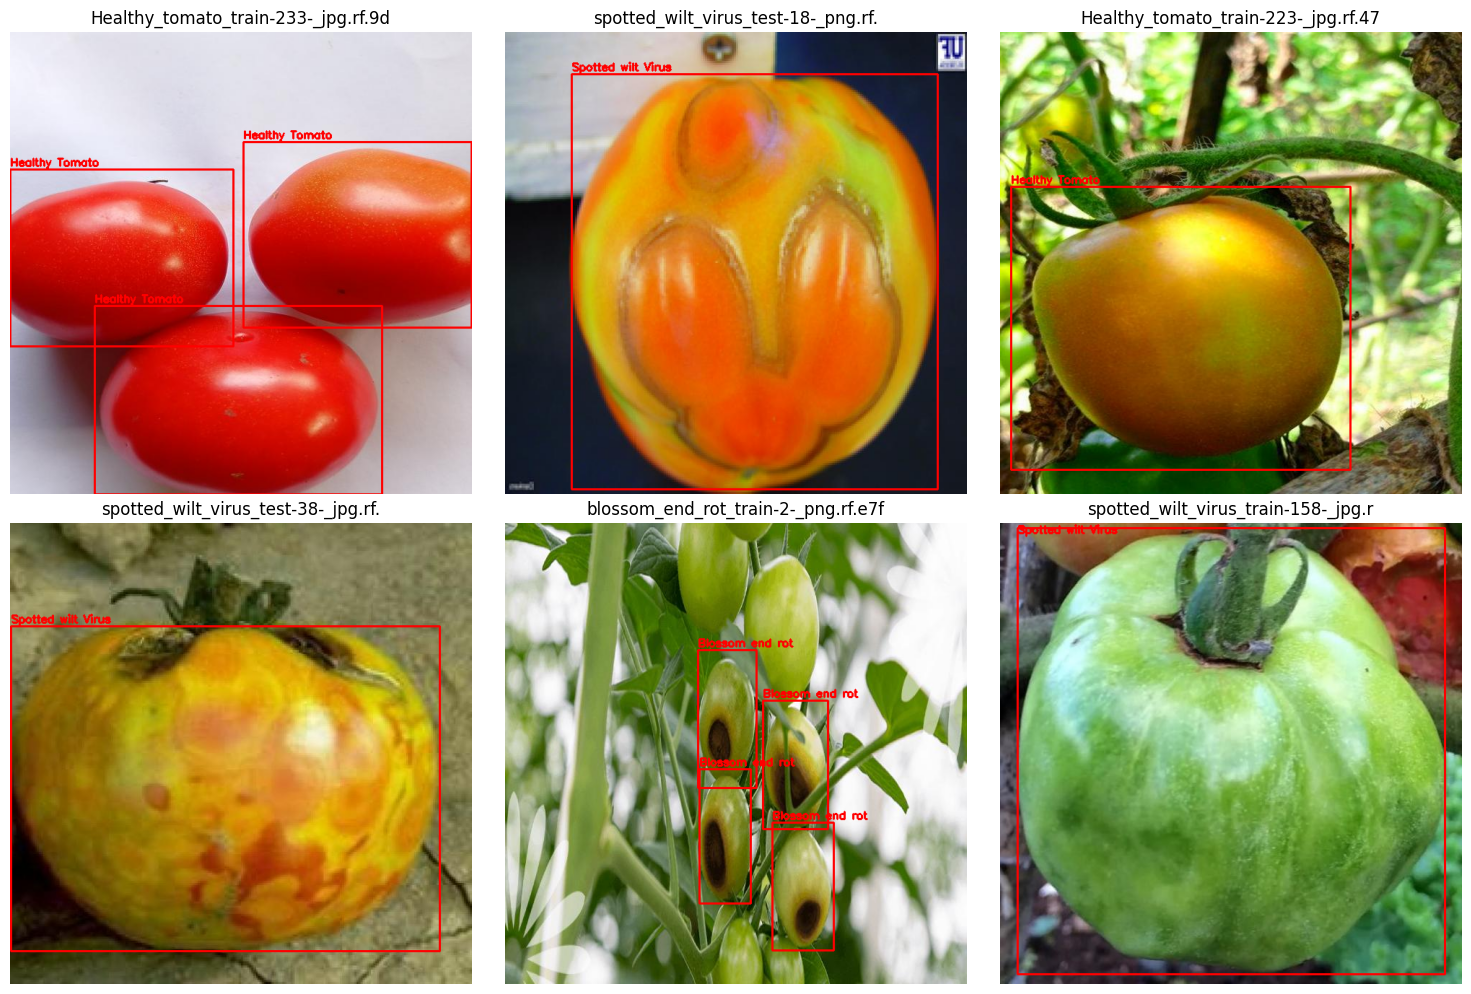

In [ ]:
def yolo_to_xyxy(box, img_w, img_h):
    x_center, y_center, w, h = box
    x1 = int((x_center - w / 2) * img_w)
    y1 = int((y_center - h / 2) * img_h)
    x2 = int((x_center + w / 2) * img_w)
    y2 = int((y_center + h / 2) * img_h)
    return x1, y1, x2, y2

def draw_yolo_labels(image_path, label_path):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if label_path.exists():
        for line in label_path.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) != 5:
                continue
            cls_id = int(float(parts[0]))
            box = list(map(float, parts[1:]))
            x1, y1, x2, y2 = yolo_to_xyxy(box, w, h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(img, class_names[cls_id], (x1, max(y1 - 5, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
    return img

sample_images = random.sample(get_images('train'), min(6, len(get_images('train'))))

plt.figure(figsize=(15, 10))
for i, img_path in enumerate(sample_images, start=1):
    label_path = DATASET_PATH / 'train' / 'labels' / f'{img_path.stem}.txt'
    img = draw_yolo_labels(img_path, label_path)
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(img_path.name[:35])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 7. Entraînement YOLOv8 baseline

On commence avec `yolov8n.pt` car il est léger et rapide.  
Si tu as plus de temps/GPU, tu peux tester `yolov8s.pt` après.


In [ ]:
# Paramètres baseline
BASE_MODEL = 'yolov8n.pt'
RUN_NAME_BASELINE = 'tomato_yolov8n_baseline'

model = YOLO(BASE_MODEL)

results_train = model.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    project='runs/detect',
    name=RUN_NAME_BASELINE,
    plots=True,
    seed=42
)

BASELINE_DIR = Path('runs/detect') / RUN_NAME_BASELINE
BASELINE_BEST = BASELINE_DIR / 'weights' / 'best.pt'
print('Modèle baseline sauvegardé ici :', BASELINE_BEST)

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tomato_dataset/Tomato Fruit  Disease Detection.v1i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tomato_yolov8n_baseline, nbs=64, nms=False, opset=None,

KeyboardInterrupt: 

In [ ]:
from pathlib import Path

# Chercher automatiquement tous les fichiers best.pt
best_files = list(Path("/content").rglob("best.pt"))

print("Fichiers best.pt trouvés :")
for f in best_files:
    print(f)

In [ ]:
# Choisir automatiquement le best.pt du modèle baseline
BASELINE_BEST = [f for f in best_files if "tomato_yolov8n_baseline" in str(f)][0]
BASELINE_DIR = BASELINE_BEST.parent.parent

print("BASELINE_BEST :", BASELINE_BEST)
print("Existe :", BASELINE_BEST.exists())
print("BASELINE_DIR :", BASELINE_DIR)

## 8. Visualiser les résultats générés par YOLO

YOLO génère automatiquement :

- `results.png` : courbes globales ;
- `confusion_matrix.png` : matrice de confusion ;
- `results.csv` : losses et métriques par epoch ;
- `weights/best.pt` : meilleur modèle.


In [ ]:
from IPython.display import Image, display

for file_name in ['results.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png']:
    file_path = BASELINE_DIR / file_name
    if file_path.exists():
        print(f"  - {file_name}")
        display(Image(filename=str(file_path)))
    else:
        print(file_name, 'introuvable pour le moment.')

## 9. Validation du modèle baseline

Métriques YOLO principales :

- **Precision** : parmi les détections du modèle, combien sont correctes ;
- **Recall** : parmi les objets réels, combien sont détectés ;
- **mAP50** : performance de détection avec IoU 0.50 ;
- **mAP50-95** : performance plus stricte sur plusieurs seuils IoU.


In [ ]:
baseline_model = YOLO(str(BASELINE_BEST))

val_metrics_baseline = baseline_model.val(
    data=str(DATA_YAML),
    split='val',
    imgsz=640,
    plots=True,
    name='baseline_validation'
)

baseline_val_summary = {
    'precision': float(val_metrics_baseline.box.mp),
    'recall': float(val_metrics_baseline.box.mr),
    'mAP50': float(val_metrics_baseline.box.map50),
    'mAP50_95': float(val_metrics_baseline.box.map)
}

baseline_val_summary

## 10. Analyse train loss vs validation loss

YOLOv8 utilise principalement :

- `box_loss` : erreur sur la localisation des bounding boxes ;
- `cls_loss` : erreur de classification ;
- `dfl_loss` : Distribution Focal Loss pour améliorer la qualité des boxes.


In [ ]:
results_csv = BASELINE_DIR / 'results.csv'
assert results_csv.exists(), 'results.csv introuvable. Vérifie que l’entraînement est terminé.'

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()
print(df.columns.tolist())
df.tail()

In [ ]:
def plot_train_val_loss(df, train_col, val_col, title):
    plt.figure(figsize=(10, 5))
    plt.plot(df['epoch'], df[train_col], label=train_col)
    plt.plot(df['epoch'], df[val_col], label=val_col)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_train_val_loss(df, 'train/box_loss', 'val/box_loss', 'Train vs Validation Box Loss')
plot_train_val_loss(df, 'train/cls_loss', 'val/cls_loss', 'Train vs Validation Classification Loss')
plot_train_val_loss(df, 'train/dfl_loss', 'val/dfl_loss', 'Train vs Validation DFL Loss')

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
plt.plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Validation metrics during training')
plt.legend()
plt.grid(True)
plt.show()

## 11. Détection automatique de l’overfitting

Règle simple :

- si `val_loss > train_loss` avec un grand écart, c’est un signe possible d’overfitting ;
- si les métriques de validation stagnent ou diminuent alors que la loss train continue de diminuer, c’est aussi un signe possible d’overfitting.

> Attention : en détection d’objets, l’accuracy classique n’est pas la métrique principale. On utilise surtout `precision`, `recall`, `mAP50`, `mAP50-95`.


In [ ]:
def overfitting_report(df, threshold_ratio=1.25):
    last = df.iloc[-1]
    report = {}

    for loss_name in ['box_loss', 'cls_loss', 'dfl_loss']:
        train_loss = float(last[f'train/{loss_name}'])
        val_loss = float(last[f'val/{loss_name}'])
        ratio = val_loss / train_loss if train_loss > 0 else np.inf
        report[loss_name] = {
            'train': train_loss,
            'val': val_loss,
            'val_train_ratio': ratio,
            'possible_overfitting': ratio > threshold_ratio
        }

    return report

overfit_report = overfitting_report(df)
overfit_report

In [ ]:
for loss_name, values in overfit_report.items():
    print(f'{loss_name}: train={values["train"]:.4f}, val={values["val"]:.4f}, ratio={values["val_train_ratio"]:.2f}')

if any(v['possible_overfitting'] for v in overfit_report.values()):
    print('Conclusion : signe possible d’overfitting. On peut essayer data augmentation + lr plus petit + régularisation.')
else:
    print('Conclusion : pas de signe fort d’overfitting selon les losses finales.')

## 12. Entraînement amélioré avec data augmentation et réglage hyperparamètres

Cette partie sert si on observe de l’overfitting ou si les performances sont faibles.

Ajustements :

- learning rate plus petit `lr0=0.001` ;
- `weight_decay` pour régulariser ;
- rotations, translations, scale ;
- flip horizontal ;
- changements HSV ;
- `mosaic` et `mixup` pour rendre le modèle plus robuste.

Tu peux mettre `RUN_AUGMENTED_TRAINING = False` si tu n’as pas le temps.


In [ ]:
RUN_AUGMENTED_TRAINING = True  # Mets False si tu veux sauter cette partie
RUN_NAME_AUG = 'tomato_yolov8n_augmented'

if RUN_AUGMENTED_TRAINING:
    model_aug = YOLO(BASE_MODEL)

    results_aug = model_aug.train(
        data=str(DATA_YAML),
        epochs=80,
        imgsz=640,
        batch=16,
        patience=15,
        project='runs/detect',
        name=RUN_NAME_AUG,
        seed=42,
        plots=True,

        # Hyperparamètres / régularisation
        lr0=0.001,
        weight_decay=0.0005,

        # Data augmentation
        degrees=10,
        translate=0.1,
        scale=0.5,
        fliplr=0.5,
        mosaic=1.0,
        mixup=0.1,
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4
    )

    AUG_DIR = Path('runs/detect') / RUN_NAME_AUG
    AUG_BEST = AUG_DIR / 'weights' / 'best.pt'
    print('Modèle amélioré sauvegardé ici :', AUG_BEST)
else:
    AUG_DIR = None
    AUG_BEST = None
    print('Entraînement augmenté ignoré.')

## 13. Validation du modèle amélioré et comparaison baseline vs augmentation

In [ ]:
comparison_rows = []
comparison_rows.append({'model': 'baseline', **baseline_val_summary})

if RUN_AUGMENTED_TRAINING and AUG_BEST.exists():
    aug_model = YOLO(str(AUG_BEST))
    val_metrics_aug = aug_model.val(
        data=str(DATA_YAML),
        split='val',
        imgsz=640,
        plots=True,
        name='augmented_validation'
    )
    aug_val_summary = {
        'precision': float(val_metrics_aug.box.mp),
        'recall': float(val_metrics_aug.box.mr),
        'mAP50': float(val_metrics_aug.box.map50),
        'mAP50_95': float(val_metrics_aug.box.map)
    }
    comparison_rows.append({'model': 'augmented', **aug_val_summary})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

In [ ]:
# Choix automatique du modèle final selon mAP50-95 validation
best_row = comparison_df.sort_values('mAP50_95', ascending=False).iloc[0]
BEST_MODEL_NAME = best_row['model']

if BEST_MODEL_NAME == 'augmented':
    FINAL_MODEL_PATH = AUG_BEST
else:
    FINAL_MODEL_PATH = BASELINE_BEST

print('Meilleur modèle selon validation mAP50-95 :', BEST_MODEL_NAME)
print('FINAL_MODEL_PATH =', FINAL_MODEL_PATH)

## 14. Test final

Le test final se fait seulement à la fin, avec le meilleur modèle choisi sur la validation.


In [ ]:
final_model = YOLO(str(FINAL_MODEL_PATH))

test_metrics = final_model.val(
    data=str(DATA_YAML),
    split='test',
    imgsz=640,
    plots=True,
    name='final_test'
)

test_summary = {
    'precision': float(test_metrics.box.mp),
    'recall': float(test_metrics.box.mr),
    'mAP50': float(test_metrics.box.map50),
    'mAP50_95': float(test_metrics.box.map)
}

test_summary

## 15. Métriques de classification par objet détecté

YOLO donne déjà les métriques de détection.  
Ici, on ajoute une évaluation **classification** : après avoir associé chaque prédiction à une vraie box avec IoU ≥ 0.50, on calcule :

- accuracy ;
- precision ;
- recall ;
- F1-score ;
- rapport de classification ;
- matrice de confusion.

Cette accuracy est donc une **accuracy de classification sur les objets correctement appariés**, pas une accuracy image-level.


In [ ]:
def load_yolo_labels(label_path, img_w, img_h):
    boxes = []
    if not label_path.exists():
        return boxes
    lines = label_path.read_text().strip().splitlines()
    for line in lines:
        parts = line.split()
        if len(parts) != 5:
            continue
        cls_id = int(float(parts[0]))
        x, y, w, h = map(float, parts[1:])
        x1, y1, x2, y2 = yolo_to_xyxy([x, y, w, h], img_w, img_h)
        boxes.append({'cls': cls_id, 'box': np.array([x1, y1, x2, y2], dtype=float)})
    return boxes

def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter_area = inter_w * inter_h

    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])
    union = area1 + area2 - inter_area

    if union == 0:
        return 0
    return inter_area / union

def evaluate_object_classification(model, split='test', conf=0.25, iou_threshold=0.5):
    images = get_images(split)
    y_true, y_pred = [], []
    tp, fp, fn = 0, 0, 0

    for img_path in images:
        img = cv2.imread(str(img_path))
        img_h, img_w = img.shape[:2]
        label_path = DATASET_PATH / split / 'labels' / f'{img_path.stem}.txt'
        gt_boxes = load_yolo_labels(label_path, img_w, img_h)

        pred_results = model.predict(str(img_path), conf=conf, verbose=False)
        pred_boxes = []
        for r in pred_results:
            if r.boxes is None:
                continue
            for box in r.boxes:
                xyxy = box.xyxy.cpu().numpy()[0]
                cls_id = int(box.cls.cpu().numpy()[0])
                score = float(box.conf.cpu().numpy()[0])
                pred_boxes.append({'cls': cls_id, 'box': xyxy, 'conf': score})

        matched_pred_idx = set()

        # Matching greedy : chaque ground truth prend la prédiction avec le meilleur IoU
        for gt in gt_boxes:
            best_iou = 0
            best_idx = None
            for idx, pred in enumerate(pred_boxes):
                if idx in matched_pred_idx:
                    continue
                iou = compute_iou(gt['box'], pred['box'])
                if iou > best_iou:
                    best_iou = iou
                    best_idx = idx

            if best_idx is not None and best_iou >= iou_threshold:
                matched_pred_idx.add(best_idx)
                tp += 1
                y_true.append(gt['cls'])
                y_pred.append(pred_boxes[best_idx]['cls'])
            else:
                fn += 1

        fp += len(pred_boxes) - len(matched_pred_idx)

    result = {
        'split': split,
        'matched_objects': len(y_true),
        'tp_localization': tp,
        'fp_detection': fp,
        'fn_detection': fn,
        'classification_accuracy_on_matched_objects': accuracy_score(y_true, y_pred) if len(y_true) > 0 else None,
        'classification_precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0) if len(y_true) > 0 else None,
        'classification_recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0) if len(y_true) > 0 else None,
        'classification_f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0) if len(y_true) > 0 else None,
        'y_true': y_true,
        'y_pred': y_pred
    }
    return result

classification_eval_test = evaluate_object_classification(final_model, split='test', conf=0.25, iou_threshold=0.5)

for k, v in classification_eval_test.items():
    if k not in ['y_true', 'y_pred']:
        print(k, ':', v)

In [ ]:
y_true = classification_eval_test['y_true']
y_pred = classification_eval_test['y_pred']

if len(y_true) > 0:
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    plt.figure(figsize=(8, 6))
    plt.imshow(cm)
    plt.title('Matrice de confusion - classification des objets appariés')
    plt.xlabel('Classe prédite')
    plt.ylabel('Classe réelle')
    plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
    plt.yticks(range(num_classes), class_names)

    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.colorbar()
    plt.tight_layout()
    plt.show()
else:
    print('Aucun objet apparié. Essaie de baisser conf ou de vérifier les labels.')

## 16. Prédiction finale sur des images de test

On sauvegarde les images annotées par le modèle dans `runs/detect/tomato_predictions/`.


In [ ]:
pred_results = final_model.predict(
    source=str(DATASET_PATH / "test" / "images"),
    imgsz=640,
    conf=0.25,
    save=True,
    project="/content/runs/detect",
    name="tomato_predictions"
)

PRED_DIR = Path("/content/runs/detect/tomato_predictions")

In [ ]:
# Afficher quelques prédictions sauvegardées
pred_images = sorted([p for p in PRED_DIR.glob('*') if p.suffix.lower() in IMG_EXTS])

if len(pred_images) > 0:
    sample_preds = random.sample(pred_images, min(6, len(pred_images)))
    plt.figure(figsize=(15, 10))
    for i, img_path in enumerate(sample_preds, start=1):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(2, 3, i)
        plt.imshow(img)
        plt.title(img_path.name[:35])
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Aucune image prédite trouvée.')

## 17. Sauvegarde du modèle final `best.pt` et des rapports

Le fichier important pour l’application finale est `best.pt`.  
On le copie sous un nom clair : `best_tomato_yolov8.pt`.


In [ ]:
FINAL_EXPORT = Path('/content/best_tomato_yolov8.pt')
shutil.copy(FINAL_MODEL_PATH, FINAL_EXPORT)
print('Modèle final copié ici :', FINAL_EXPORT)

# Sauvegarde des tableaux métriques
REPORT_DIR = Path('/content/reports')
REPORT_DIR.mkdir(exist_ok=True)

comparison_df.to_csv(REPORT_DIR / 'model_comparison_validation.csv', index=False)
pd.DataFrame([test_summary]).to_csv(REPORT_DIR / 'final_test_metrics.csv', index=False)

# Zipper les rapports et quelques outputs YOLO
shutil.make_archive('/content/tomato_yolov8_reports', 'zip', REPORT_DIR)
print('Rapports zippés : /content/tomato_yolov8_reports.zip')